In [12]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [5]:

# Carregamento dos dados brutos e união para gerar o formato de vendas esperado
df_products = pd.read_csv("../data/product.csv")
df_product_variants = pd.read_csv("../data/product_variant.csv")
df_orders = pd.read_csv("../data/order.csv")
df_orders_items = pd.read_csv("../data/order_item.csv")


In [7]:

# Identifica a coluna de cliente dinamicamente
cust_col = [col for col in df_orders.columns if 'customer' in col or 'client' in col or 'user' in col][0]

# Unificação para associar cliente ao produto base
df_iv = pd.merge(df_orders_items, df_product_variants, left_on='product_variant_id', right_on='id', suffixes=('', '_var'))
df_ipo = pd.merge(df_iv, df_orders, left_on='order_id', right_on='id', suffixes=('', '_ord'))

df_vendas = df_ipo[[cust_col, 'product_id', 'quantity']].copy()
df_vendas.columns = ['id_client', 'id_product', 'qtd']

df_produtos = df_products[['id', 'name']].copy()
df_produtos.columns = ['code', 'name']



In [8]:
df_interacao = df_vendas.groupby(['id_client', 'id_product'])['qtd'].sum().reset_index()
df_interacao['comprou'] = 1

# Pivota: linhas = clientes, colunas = produtos, valor = 0 ou 1
matriz = df_interacao.pivot_table(
    index='id_client',
    columns='id_product',
    values='comprou',
    fill_value=0
)

In [9]:
matriz_T = matriz.T

sim = cosine_similarity(matriz_T)

df_similares = pd.DataFrame(
    sim,
    index=matriz_T.index,
    columns=matriz_T.index
)

produto_referencia = 'Motor de Popa 1949'
ids_ref = df_produtos[df_produtos['name'] == produto_referencia]['code'].tolist()
print(f"\nProduto de referência: {produto_referencia} (IDs: {ids_ref})")



Produto de referência: Motor de Popa 1949 (IDs: [180])


In [10]:
# Trata eventuais IDs múltiplos e remove o próprio produto do ranking
similares = df_similares.loc[ids_ref].mean(axis=0).drop(ids_ref, errors='ignore')  

top5 = similares.sort_values(ascending=False).head(5).reset_index()
top5.columns = ['id_product', 'similaridade']
top5 = top5.merge(df_produtos[['code', 'name']], left_on='id_product', right_on='code')

print("\nTop 5 produtos recomendados:")
print(top5[['code', 'name', 'similaridade']].to_string(index=False))


Top 5 produtos recomendados:
 code               name  similaridade
  389 Motor de Popa 5331      0.256553
  295  Cabo Náutico 2105      0.256239
   75   Vela Mestra 1913      0.255785
  337  Cabo Náutico 9048      0.239332
   55   GPS Plotter 6249      0.237744


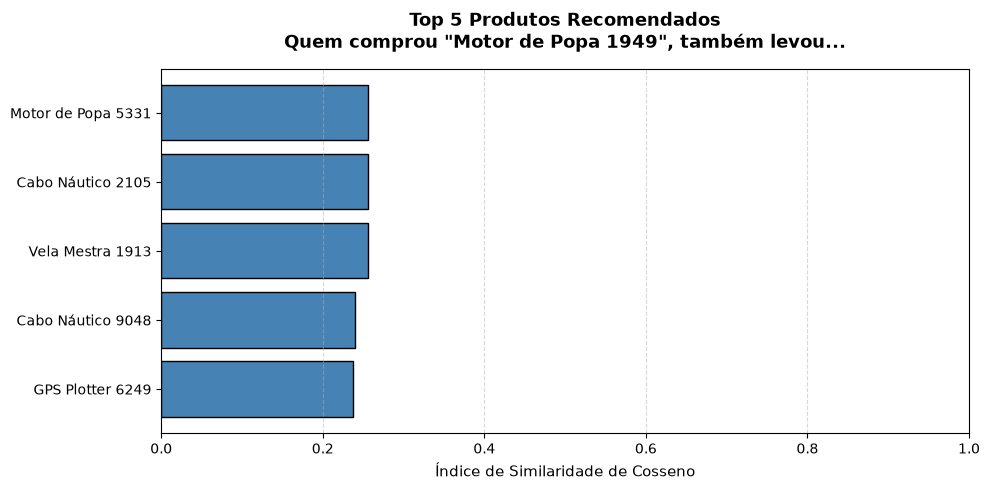


Gráfico salvo com sucesso em: '../docs/reports/recomendacao_motor_popa.png'


In [13]:
# --- GERAÇÃO E SALVAMENTO DA IMAGEM (GRÁFICO) ---
plt.figure(figsize=(10, 5))
# Invertemos a ordem para o mais similar ficar no topo do gráfico de barras horizontais
plt.barh(
    top5['name'][::-1],
    top5['similaridade'][::-1],
    color='steelblue',
    edgecolor='black',
)
plt.xlabel('Índice de Similaridade de Cosseno', fontsize=11)
plt.title(
    f'Top 5 Produtos Recomendados\nQuem comprou "{produto_referencia}", também levou...',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlim(0, 1.0)  # A similaridade de cosseno varia de 0 a 1
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Salva a imagem na pasta de relatórios
plt.savefig(
    '../docs/reports/recomendacao_motor_popa.png', dpi=150, bbox_inches='tight'
)
plt.show()
print(
    "\nGráfico salvo com sucesso em: '../docs/reports/recomendacao_motor_popa.png'"
)